In [2]:
import  matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
import random as rn
import scipy.ndimage
from scipy.interpolate import griddata
import numpy.ma as ma
from numpy.random import uniform, seed
import time
import eif as iso
import eif_new as iso1
import seaborn as sb
from sklearn.ensemble import IsolationForest

In [3]:
# Create data
n_records = 5000
n_dimensions = 100
np.random.seed(1)

X = np.random.uniform(0, 1, (n_records, n_dimensions))

In [4]:
rng = np.random.RandomState(42)

In [5]:
Ntrees = 2000
Nsamples = 256

In [7]:
ss = time.time()
F1 = iso1.iForest(X, ntrees=Ntrees, sample_size=Nsamples, extension_level=n_dimensions-1, seed=42, n_jobs=-1)
S1 = F1.compute_paths_parallel(X_in=X)
ee = time.time()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   8 | elapsed:  4.4min remaining: 13.2min
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:  4.5min finished


In [8]:
print('{:.3f} sec, EIF parallel Python Version'.format(ee-ss))

284.144 sec, EIF parallel Python Version


In [9]:
ss = time.time()
F2 = iso.iForest(X, ntrees=Ntrees, sample_size=Nsamples, ExtensionLevel=n_dimensions-1, seed=42)
S2 = F2.compute_paths(X_in=X, parallel=False)
ee = time.time()

In [10]:
print('{:.3f} sec, EIF non-parallel Cython Version'.format(ee-ss))

30.092 sec, EIF non-parallel Cython Version


In [11]:
ss = time.time()
F3 = iso.iForest(X, ntrees=Ntrees, sample_size=Nsamples, ExtensionLevel=n_dimensions-1, seed=42)
S3 = F3.compute_paths(X_in=X, parallel=True)
ee = time.time()

In [12]:
print('{:.3f} sec, EIF parallel Cython Version'.format(ee-ss))

10.977 sec, EIF parallel Cython Version


Text(0.5, 0, 'Scores')

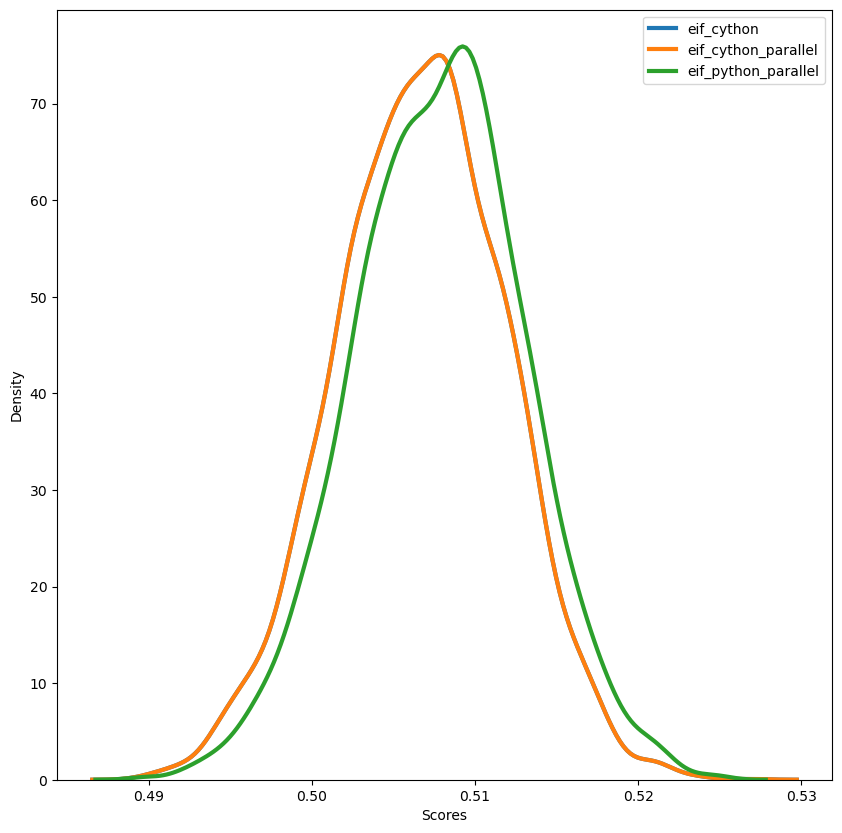

In [14]:
plt.figure(figsize=(10,10))
sb.kdeplot(S1, lw=3, label='eif_cython',  clip=(0.35, 0.8))
sb.kdeplot(S2, lw=3, label='eif_cython_parallel',  clip=(0.35, 0.8))
sb.kdeplot(S3, lw=3, label='eif_python_parallel',  clip=(0.35, 0.8))
plt.legend(loc=0)
plt.xlabel('Scores')

In [10]:
S1

array([0.51024279, 0.51599871, 0.50365362, ..., 0.51260066, 0.50380661,
       0.50718989], shape=(5000,))

In [11]:
S2

array([0.51024279, 0.51599871, 0.50365362, ..., 0.51260066, 0.50380661,
       0.50718989], shape=(5000,))